In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import tensorflow as tf

In [3]:
def plot_training_history(history, prefix="Model"):
    history_dict = history.history
    epochs = range(len(history_dict["loss"]))

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, history_dict["accuracy"], label="Train")
    plt.plot(epochs, history_dict["val_accuracy"], label="Validation")
    plt.title(f"{prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.plot(epochs, history_dict["precision"], label="Train")
    plt.plot(epochs, history_dict["val_precision"], label="Validation")
    plt.title(f"{prefix} Precision")
    plt.xlabel("Epoch")
    plt.ylabel("Precision")
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.plot(epochs, history_dict["recall"], label="Train")
    plt.plot(epochs, history_dict["val_recall"], label="Validation")
    plt.title(f"{prefix} Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend()

    plt.subplot(2, 2, 4)
    plt.plot(epochs, history_dict["loss"], label="Train")
    plt.plot(epochs, history_dict["val_loss"], label="Validation")
    plt.title(f"{prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [4]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    loss, accuracy, precision, recall = model.evaluate(X_test, y_test, verbose=0)
    print("Test loss:", loss)

    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob >= threshold).astype(int).flatten()

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure()
    plt.imshow(cm, cmap="coolwarm")
    plt.title("Matriz de confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.xticks([0, 1], ["<=50K", ">50K"])
    plt.yticks([0, 1], ["<=50K", ">50K"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.show()

    return {
        "loss": loss,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

# Análisis exploratorio

In [5]:
df = pd.read_csv("../dataset/adult.csv", na_values=["?"], skipinitialspace=True)

In [6]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
print(df.size)
print(df.shape)

732630
(48842, 15)


In [8]:
df.isna().sum()

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

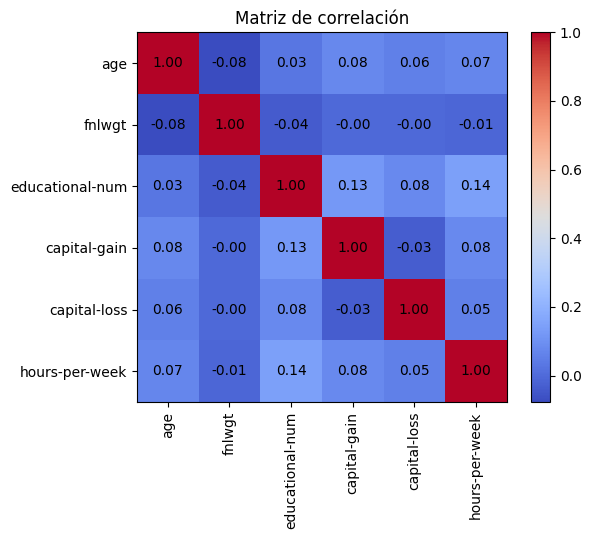

In [9]:
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        value = corr.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha="center", va="center")
plt.title("Matriz de correlación")
plt.show()

# Preprocesamiento antes de data splitting

In [10]:
# Eliminar variables duplicadas y no relevantes
df = df.drop(columns=["educational-num", "fnlwgt"])

In [11]:
# Reemplazar valores faltantes por "Unknown"
df["workclass"] = df["workclass"].fillna("Unknown")
df["occupation"] = df["occupation"].fillna("Unknown")
df["native-country"] = df["native-country"].fillna("Unknown")

In [12]:
# separarar features y target
X = df.drop("income", axis=1)
y = df["income"]

# quitar "." de valores como "<=50K." y ">50K."
y = y.str.replace(".", "", regex=False)
# convertir strings a 0 y 1 (binario)
y = y.map({"<=50K": 0, ">50K": 1})

In [13]:
y.value_counts()

income
0    37155
1    11687
Name: count, dtype: int64

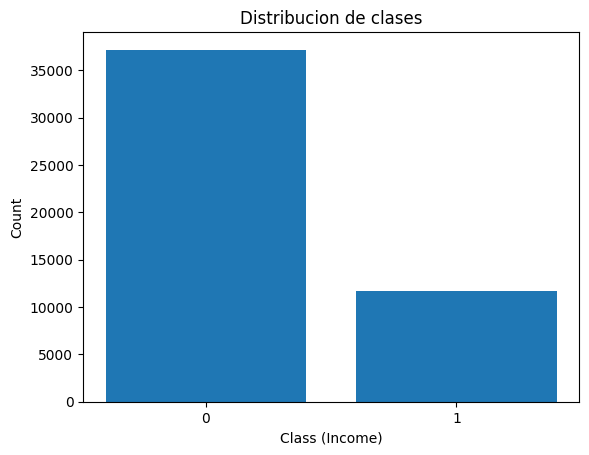

In [14]:
counts = y.value_counts()
plt.figure()
plt.bar(counts.index.astype(str), counts.values)
plt.xlabel("Class (Income)")
plt.ylabel("Count")
plt.title("Distribucion de clases")
plt.show()

In [15]:
X

,age,workclass,education,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,Unknown,Some-college,Never-married,Unknown,Own-child,White,Female,0,0,30,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States
48838,40,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States
48839,58,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
48840,22,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States


# Data splitting

In [16]:
from sklearn.model_selection import train_test_split
# Separar en dataset de training y dataset de testing
X_train_full, X_test_raw, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Preprocesamiento después de data splitting

In [17]:
# Identificar variables numéricas y categóricas
categorical_cols = X_train_full.select_dtypes(include=["object", "string", "category"]).columns
numerical_cols = X_train_full.select_dtypes(exclude=["object", "string", "category"]).columns

print("Categorical columns:", list(categorical_cols))
print("Numerical columns:", list(numerical_cols))

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']
Numerical columns: ['age', 'capital-gain', 'capital-loss', 'hours-per-week']


In [18]:
# Escalado necesario para variables numéricas y one-hot encoding para variables categóricas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train_full)
X_test_processed = preprocessor.transform(X_test_raw)

# guardar preprocessor para su uso en modelos ya guardados
joblib.dump(preprocessor, "../modelos/preprocessor.pkl")

['../modelos/preprocessor.pkl']

# Implementaciòn del modelo

In [258]:
from tensorflow.keras import Sequential, Input, optimizers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [259]:
input_dim = X_train_processed.shape[1]
model1 = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])


In [260]:
model1.compile(
    optimizer=optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [261]:
model1.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │         6,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

In [262]:
history_model1 = model1.fit(
    X_train_processed,
    y_train_full,
    validation_split=0.2,
    epochs=18,
    batch_size=32,
    verbose=2
)


Epoch 1/18
977/977 - 3s - 3ms/step - accuracy: 0.8438 - loss: 0.3304 - precision: 0.7143 - recall: 0.5816 - val_accuracy: 0.8513 - val_loss: 0.3179 - val_precision: 0.7596 - val_recall: 0.5446
Epoch 2/18
977/977 - 2s - 2ms/step - accuracy: 0.8561 - loss: 0.3065 - precision: 0.7339 - recall: 0.6276 - val_accuracy: 0.8558 - val_loss: 0.3165 - val_precision: 0.7215 - val_recall: 0.6370
Epoch 3/18
977/977 - 2s - 2ms/step - accuracy: 0.8591 - loss: 0.3024 - precision: 0.7442 - recall: 0.6288 - val_accuracy: 0.8534 - val_loss: 0.3203 - val_precision: 0.7020 - val_recall: 0.6618
Epoch 4/18
977/977 - 2s - 2ms/step - accuracy: 0.8598 - loss: 0.2994 - precision: 0.7467 - recall: 0.6291 - val_accuracy: 0.8554 - val_loss: 0.3176 - val_precision: 0.7255 - val_recall: 0.6267
Epoch 5/18
977/977 - 2s - 2ms/step - accuracy: 0.8611 - loss: 0.2963 - precision: 0.7482 - recall: 0.6347 - val_accuracy: 0.8549 - val_loss: 0.3186 - val_precision: 0.7559 - val_recall: 0.5721
Epoch 6/18
977/977 - 2s - 2ms/step 

In [263]:
model1.save("../modelos/modelo_basico.keras")

# Evaluación inicial del modelo

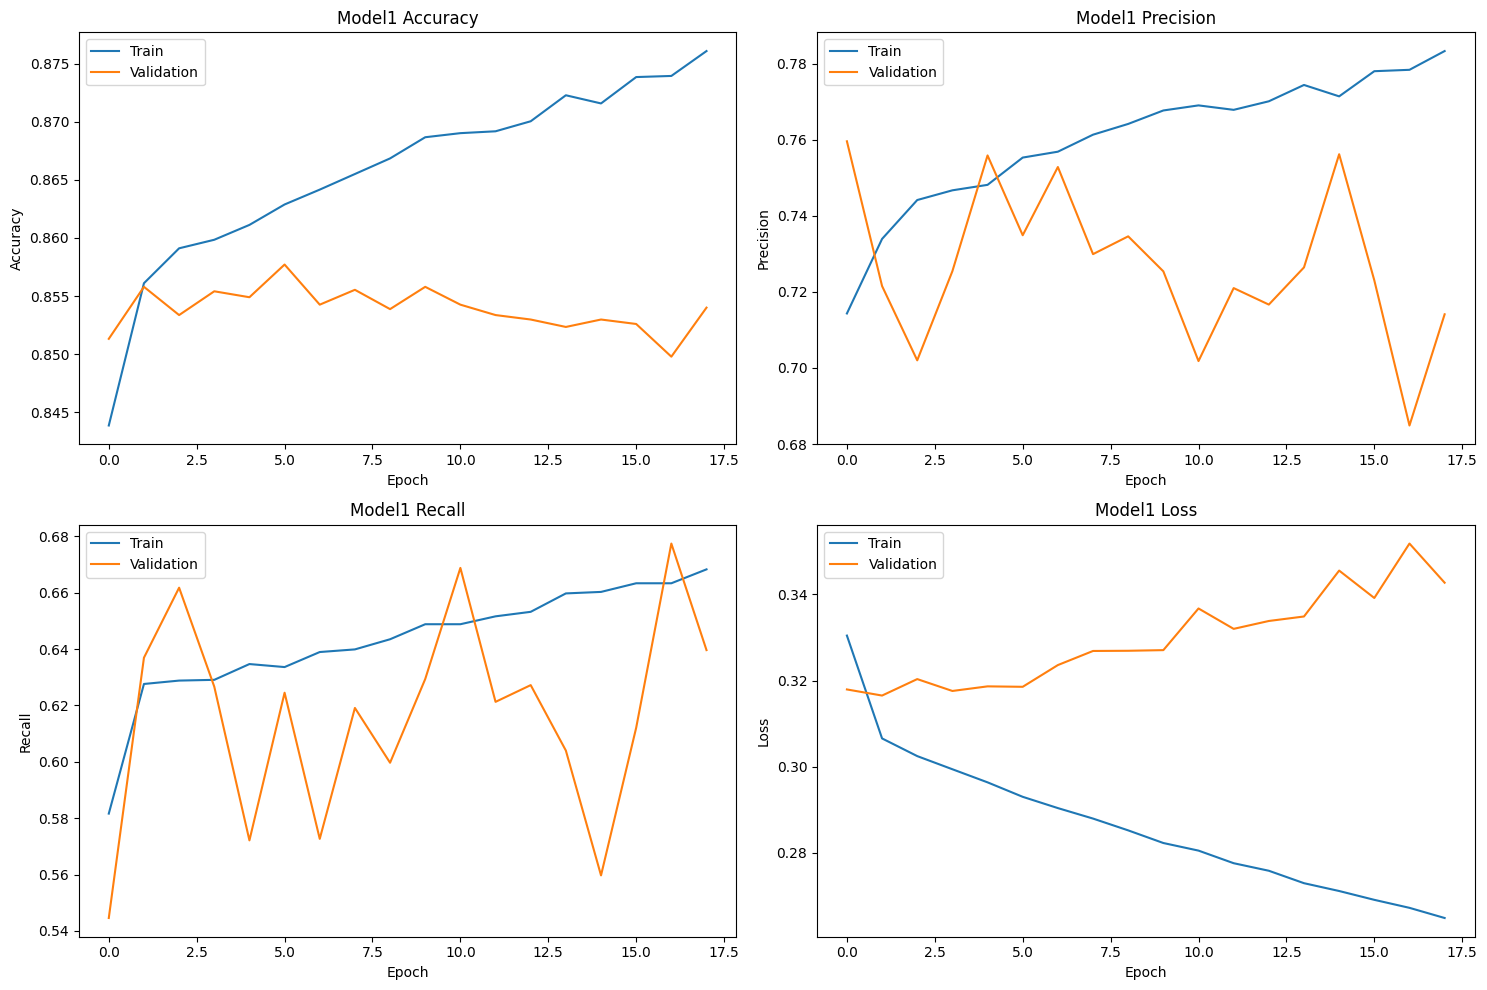

In [264]:
plot_training_history(history_model1, prefix="Model1")

Test loss: 0.3236144483089447
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8565871634763026
Precision: 0.7253487253487253
Recall: 0.6449957228400343
F1-score: 0.6828163912157573


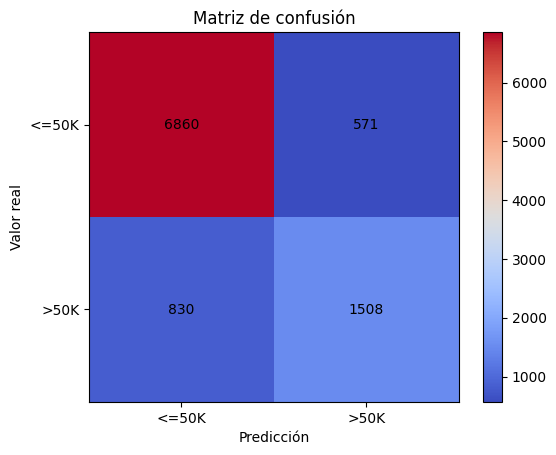

In [265]:
evaluation_model1 = evaluate_model(model1,X_test_processed,y_test)

# Modelo refinado

In [266]:
model2 = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

In [267]:
early_stopping = EarlyStopping(patience=5)

In [268]:
checkpoint = ModelCheckpoint(
    filepath="../modelos/modelo_mejorado.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [269]:
model2.compile(
    optimizer=optimizers.Adam(),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [270]:
model2.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         6,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,961 (35.00 KB)

 Trainable params: 8,961 (35.00 KB)

 Non-trainable params: 0 (0.00 B)

In [271]:
history_model2 = model2.fit(
    X_train_processed,
    y_train_full,
    callbacks=[early_stopping, checkpoint],
    validation_split=0.2,
    epochs=18,
    batch_size=32,
    verbose=2
)


Epoch 1/18

Epoch 1: val_loss improved from None to 0.31802, saving model to ../modelos/modelo_mejorado.keras

Epoch 1: finished saving model to ../modelos/modelo_mejorado.keras
977/977 - 4s - 4ms/step - accuracy: 0.8382 - loss: 0.3491 - precision: 0.7155 - recall: 0.5407 - val_accuracy: 0.8518 - val_loss: 0.3180 - val_precision: 0.7217 - val_recall: 0.6094
Epoch 2/18

Epoch 2: val_loss improved from 0.31802 to 0.31796, saving model to ../modelos/modelo_mejorado.keras

Epoch 2: finished saving model to ../modelos/modelo_mejorado.keras
977/977 - 2s - 2ms/step - accuracy: 0.8523 - loss: 0.3173 - precision: 0.7315 - recall: 0.6068 - val_accuracy: 0.8500 - val_loss: 0.3180 - val_precision: 0.7389 - val_recall: 0.5673
Epoch 3/18

Epoch 3: val_loss did not improve from 0.31796
977/977 - 2s - 2ms/step - accuracy: 0.8559 - loss: 0.3111 - precision: 0.7442 - recall: 0.6084 - val_accuracy: 0.8520 - val_loss: 0.3199 - val_precision: 0.7171 - val_recall: 0.6191
Epoch 4/18

Epoch 4: val_loss did no

In [272]:
model2 = tf.keras.models.load_model("../modelos/modelo_mejorado.keras")

# Evaluación del modelo refinado

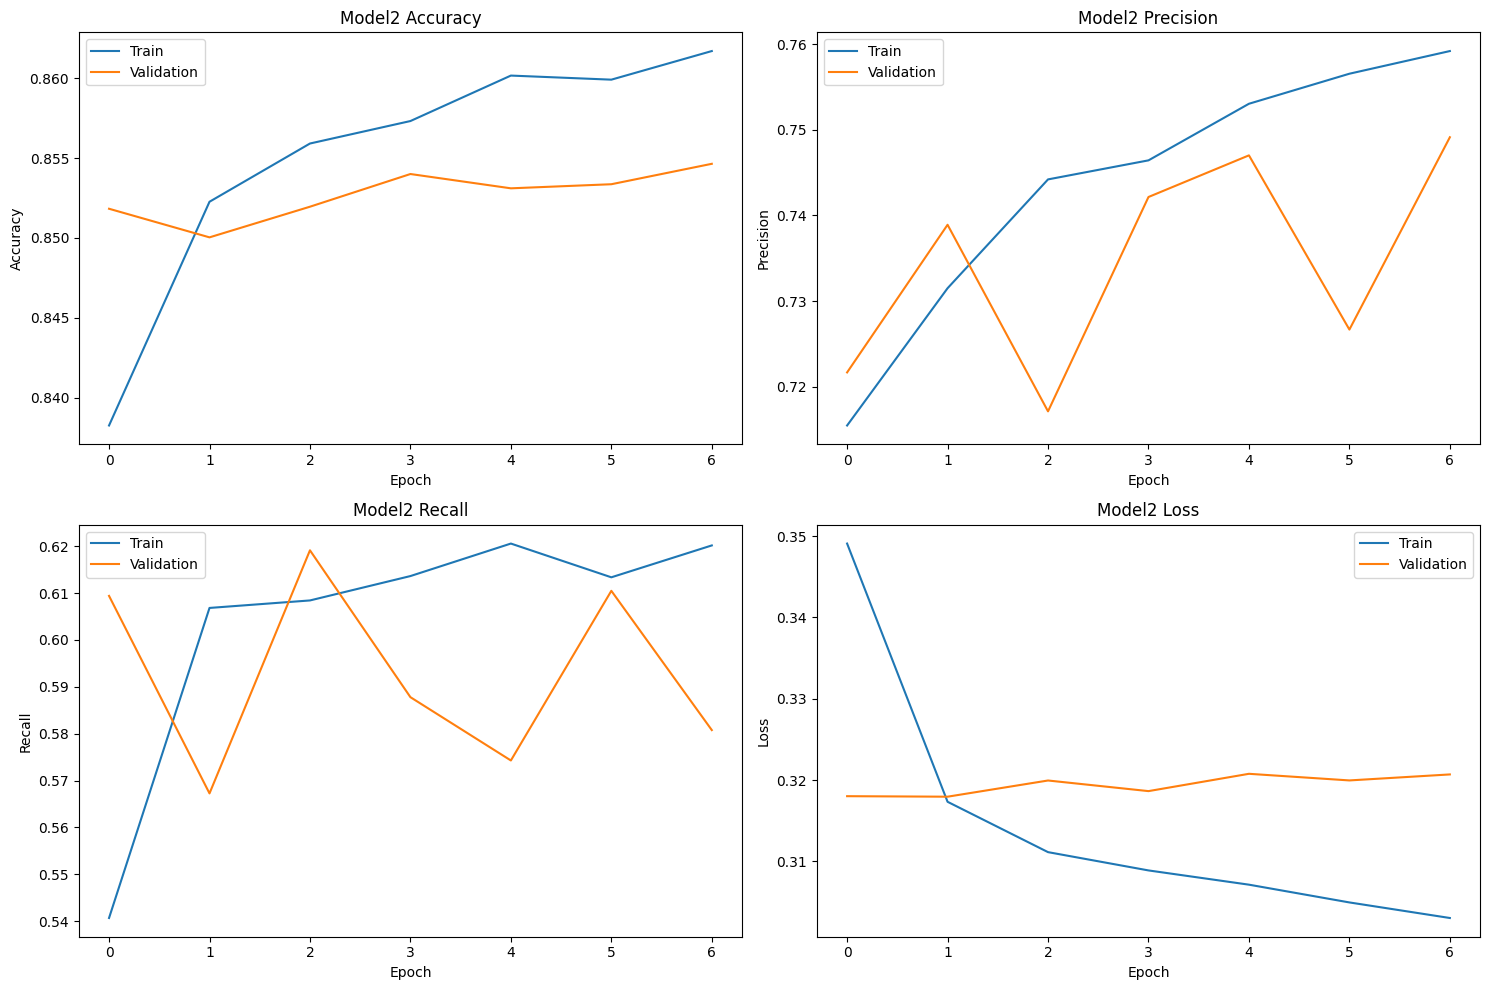

In [273]:
plot_training_history(history_model2, prefix="Model2")

Carga posterior de los modelos

In [19]:
preprocessor = joblib.load("../modelos/preprocessor.pkl")
modelo_basico = tf.keras.models.load_model("../modelos/modelo_basico.keras")
modelo_mejorado = tf.keras.models.load_model("../modelos/modelo_mejorado.keras")

In [33]:
X_test_processed = preprocessor.transform(X_test_raw)

pred_modelo_basico = modelo_basico.predict(X_test_processed)
pred_modelo_mejorado = modelo_mejorado.predict(X_test_processed)

306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step


In [37]:
thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_t = (pred_modelo_mejorado >= t)

    f1_scores.append(f1_score(y_test, y_pred_t))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1-score:", f1_scores[best_idx])


Best threshold: 0.3699999999999999
Best F1-score: 0.6964882943143813


Test loss: 0.31028202176094055
306/306 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step
Accuracy: 0.8513665677141979
Precision: 0.6811120196238757
Recall: 0.7125748502994012
F1-score: 0.6964882943143813


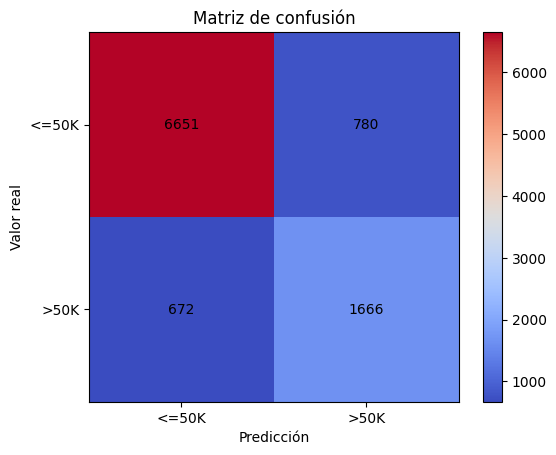

{'loss': 0.31028202176094055,
 'accuracy': 0.8513665677141979,
 'precision': 0.6811120196238757,
 'recall': 0.7125748502994012,
 'f1': 0.6964882943143813}

In [36]:
evaluate_model(modelo_mejorado, X_test_processed, y_test,best_threshold)